# Lesson ML 7: Evaluation Metrics Deep Dive

This notebook addresses the final section of the lesson: the evaluation of classification and regression models using appropriate metrics.

## 1) Classification metrics

This section examines Accuracy, Precision, Recall, F1, and ROC-AUC.

These metrics capture distinct aspects of predictive performance; the appropriate choice depends on the relative cost of false positives and false negatives.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, mean_absolute_error, root_mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
np.random.seed(42)

### Metric formulas

- Accuracy = (TP + TN) / (TP + TN + FP + FN)
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 = 2 × Precision × Recall / (Precision + Recall)
- ROC-AUC = area under the ROC curve built from prediction scores

In [2]:
# Construct an imbalanced binary classification example
X, y = make_classification(
    n_samples=1200,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    weights=[0.85, 0.15],
    class_sep=1.2,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

classification_metrics = pd.Series({
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
})
classification_metrics.to_frame('Value').round(4)

,Value
Accuracy,0.8722
Precision,0.6154
Recall,0.4364
F1,0.5106
ROC-AUC,0.7739


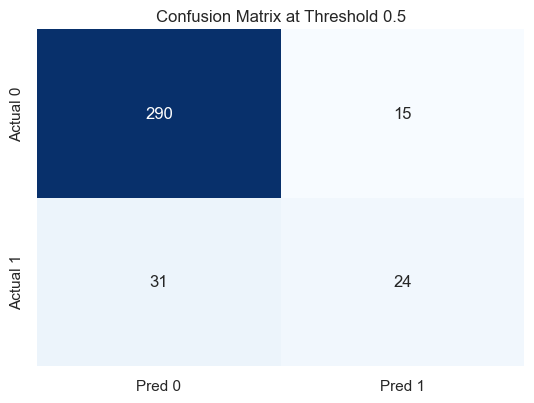

              precision    recall  f1-score   support

           0     0.9034    0.9508    0.9265       305
           1     0.6154    0.4364    0.5106        55

    accuracy                         0.8722       360
   macro avg     0.7594    0.6936    0.7186       360
weighted avg     0.8594    0.8722    0.8630       360



In [3]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
plt.figure(figsize=(5.5, 4.2))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix at Threshold 0.5')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, digits=4))

In [4]:
# Sensitivity to the classification threshold
threshold_rows = []
for threshold in [0.3, 0.5, 0.7]:
    preds = (y_prob >= threshold).astype(int)
    threshold_rows.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1': f1_score(y_test, preds, zero_division=0)
    })
pd.DataFrame(threshold_rows).round(4)

,Threshold,Accuracy,Precision,Recall,F1
0,0.3,0.8611,0.5397,0.6182,0.5763
1,0.5,0.8722,0.6154,0.4364,0.5106
2,0.7,0.8611,0.6471,0.2000,0.3056


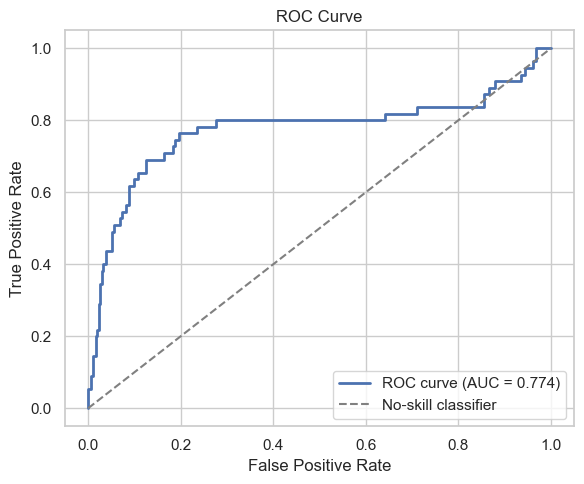

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {auc_value:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='No-skill classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 2) Regression metrics

In regression settings, continuous predictions are compared with continuous target values.

Key metrics include:
- MAE: mean absolute error
- MSE: mean squared error
- RMSE: square root of MSE
- R²: variance explained by the model

In [6]:
Xr, yr = make_regression(n_samples=800, n_features=5, n_informative=4, noise=18.0, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=42)
reg = LinearRegression()
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)
residuals = yr_test - yr_pred

regression_metrics = pd.Series({
    'MAE': mean_absolute_error(yr_test, yr_pred),
    'MSE': root_mean_squared_error(yr_test, yr_pred)**2,
    'RMSE': root_mean_squared_error(yr_test, yr_pred),
    'R2': r2_score(yr_test, yr_pred)
})
regression_metrics.to_frame('Value').round(4)

,Value
MAE,14.9285
MSE,337.5458
RMSE,18.3724
R2,0.9790


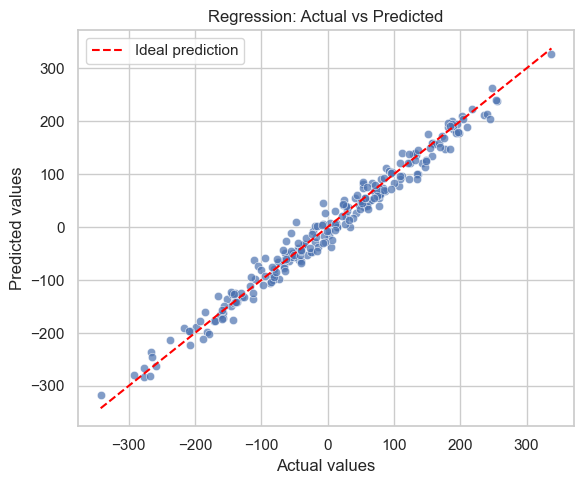

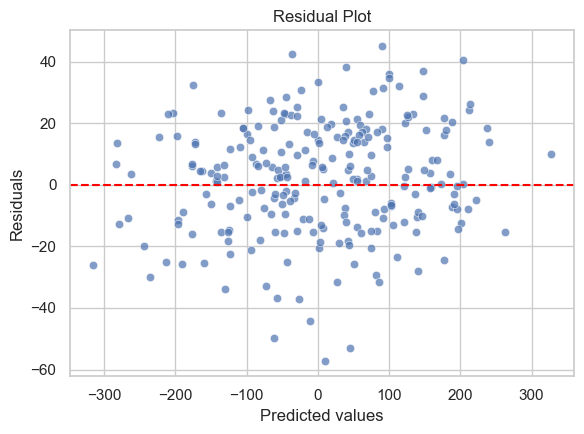

In [7]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=yr_test, y=yr_pred, alpha=0.7)
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
plt.plot(lims, lims, '--', color='red', label='Ideal prediction')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
sns.scatterplot(x=yr_pred, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## 3) Summary

- Accuracy may be misleading in imbalanced settings.
- Precision and recall capture different error costs.
- F1 provides a single summary of precision-recall balance.
- ROC-AUC measures ranking quality across all thresholds.
- For regression, MAE is directly interpretable, RMSE penalizes larger errors more strongly, and R² describes explained variance.